# 1. Install Required Libraries


In [5]:
# Install required libraries
!pip install contractions wordcloud gensim -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.3 MB/s eta 0:00:00


# 2. Import Libraries


In [6]:
import re
import string
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import contractions

from wordcloud import WordCloud
from collections import Counter

import nltk
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.regularizers import l2


import gensim.downloader as api


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
# 2. Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 3. Load Dataset


In [ ]:
DATA_PATH = "/content/drive/MyDrive/Dataset/sarcastic_headlines.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print(df.head())
print(df.columns)


Dataset shape: (28619, 2)
                                            headline  is_sarcastic
0  thirtysomething scientists unveil doomsday clo...             1
1  dem rep. totally nails why congress is falling...             0
2  eat your veggies: 9 deliciously different recipes             0
3  inclement weather prevents liar from getting t...             1
4  mother comes pretty close to using word 'strea...             1
Index(['headline', 'is_sarcastic'], dtype='object')


In [ ]:
TEXT_COLUMN = "headline"
LABEL_COLUMN = "is_sarcastic"

df = df[[TEXT_COLUMN, LABEL_COLUMN]].dropna()

print(df.head())
print(df[LABEL_COLUMN].value_counts())

                                            headline  is_sarcastic
0  thirtysomething scientists unveil doomsday clo...             1
1  dem rep. totally nails why congress is falling...             0
2  eat your veggies: 9 deliciously different recipes             0
3  inclement weather prevents liar from getting t...             1
4  mother comes pretty close to using word 'strea...             1
is_sarcastic
0    14985
1    13634
Name: count, dtype: int64


# 4. Text Preprocessing


In [ ]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """
    Cleans tweet text by:
    - lowercasing
    - expanding contractions
    - removing URLs, mentions, hashtags, numbers, and special characters
    - removing stopwords
    - lemmatizing words
    """
    text = str(text).lower()

    # Expand contractions: don't -> do not
    text = contractions.fix(text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove mentions and hashtags
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation and special characters
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize manually, remove stopwords, and lemmatize
    words = text.split()
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(words)

df["clean_text"] = df[TEXT_COLUMN].apply(clean_text)

df[[TEXT_COLUMN, "clean_text", LABEL_COLUMN]].head()


,headline,clean_text,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,thirtysomething scientist unveil doomsday cloc...,1
1,dem rep. totally nails why congress is falling...,dem rep totally nail congress falling short ge...,0
2,eat your veggies: 9 deliciously different recipes,eat veggie deliciously different recipe,0
3,inclement weather prevents liar from getting t...,inclement weather prevents liar getting work,1
4,mother comes pretty close to using word 'strea...,mother come pretty close using word streaming ...,1


# 5. Visualize Cleaned Data


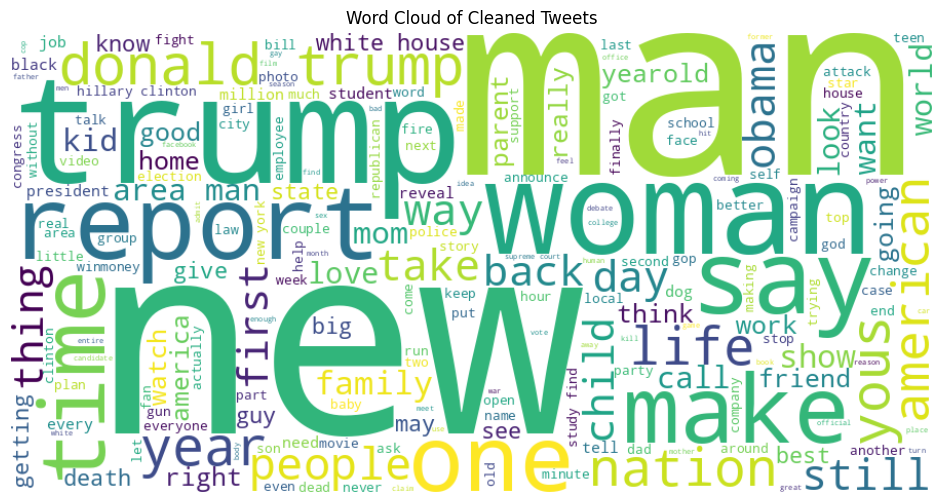

In [ ]:
all_words = " ".join(df["clean_text"])

wordcloud = WordCloud(
    width=900,
    height=450,
    background_color="white"
).generate(all_words)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Cleaned Tweets")
plt.show()


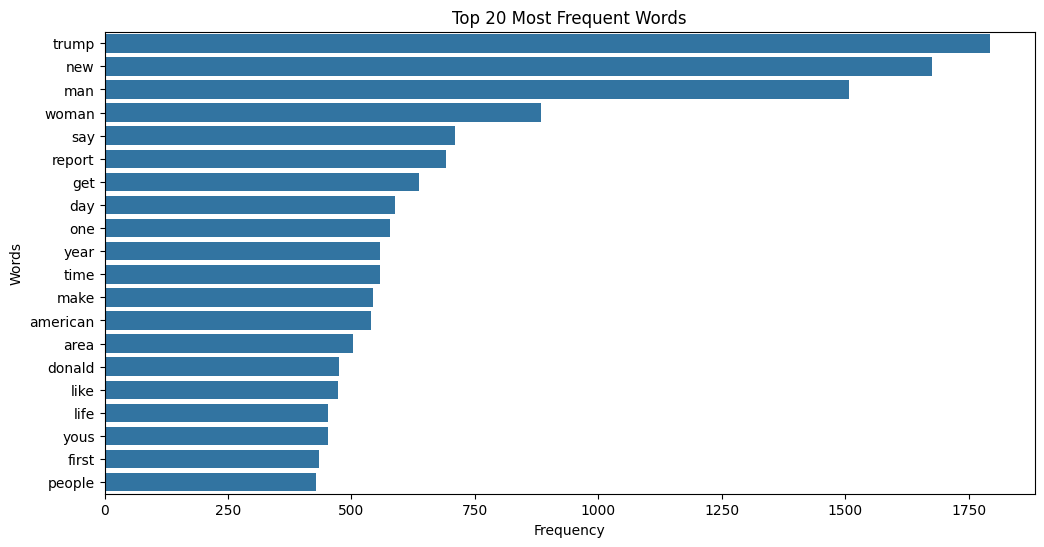

In [ ]:
word_counts = Counter(all_words.split())
most_common_words = word_counts.most_common(20)

words, counts = zip(*most_common_words)

plt.figure(figsize=(12, 6))
sns.barplot(x=list(counts), y=list(words))
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()


# 6. Encode Labels


In [ ]:
label_encoder = LabelEncoder()
df["label_encoded"] = label_encoder.fit_transform(df[LABEL_COLUMN])

num_classes = len(label_encoder.classes_)

print("Classes:", label_encoder.classes_)
print("Number of classes:", num_classes)


Classes: [0 1]
Number of classes: 2


# 7. Train-Test Split


In [ ]:
X = df["clean_text"]
y = df["label_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 22895
Testing samples: 5724


# 8. Tokenization and Percentile-Based Padding


In [ ]:
VOCAB_SIZE = 10000
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token=OOV_TOKEN
)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Percentile-based sequence length avoids very long outlier tweets
sequence_lengths = [len(seq) for seq in X_train_seq]
MAX_LEN = int(np.percentile(sequence_lengths, 95))

print("95th percentile max length:", MAX_LEN)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

vocab_size = min(VOCAB_SIZE, len(tokenizer.word_index) + 1)

print("Vocabulary size:", vocab_size)
print("Padded training shape:", X_train_pad.shape)
print("Padded testing shape:", X_test_pad.shape)


95th percentile max length: 11
Vocabulary size: 10000
Padded training shape: (22895, 11)
Padded testing shape: (5724, 11)


# 9. Model Output Settings


In [ ]:
if num_classes == 2:
    output_units = 1
    output_activation = "sigmoid"
    loss_function = "binary_crossentropy"
else:
    output_units = num_classes
    output_activation = "softmax"
    loss_function = "sparse_categorical_crossentropy"

print("Loss function:", loss_function)
print("Output activation:", output_activation)


Loss function: binary_crossentropy
Output activation: sigmoid


# 10. Model 1: Simple RNN with Trainable Embedding


In [ ]:
def build_simple_rnn_model():
    model = Sequential()

    model.add(Input(shape=(MAX_LEN,)))

    model.add(Embedding(
        input_dim=vocab_size,
        output_dim=64
    ))

    model.add(SpatialDropout1D(0.3))

    model.add(SimpleRNN(
        32,
        return_sequences=False,
        dropout=0.3,
        recurrent_dropout=0.2,
        kernel_regularizer=l2(0.001)
    ))

    model.add(Dense(
        16,
        activation="relu",
        kernel_regularizer=l2(0.001)
    ))

    model.add(Dropout(0.5))

    model.add(Dense(output_units, activation=output_activation))

    model.compile(
        optimizer="adam",
        loss=loss_function,
        metrics=["accuracy"]
    )

    return model

rnn_model = build_simple_rnn_model()
rnn_model.summary()



Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ (None, 11, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_4             │ (None, 11, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 643,649 (2.46 MB)

 Trainable params: 643,649 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

# 11. Model 2: LSTM with Trainable Embedding


In [ ]:
def build_lstm_model():
    model = Sequential()

    model.add(Input(shape=(MAX_LEN,)))

    model.add(Embedding(
        input_dim=vocab_size,
        output_dim=64
    ))

    model.add(SpatialDropout1D(0.3))

    model.add(LSTM(
        32,
        return_sequences=False,
        dropout=0.3,
        recurrent_dropout=0.2,
        kernel_regularizer=l2(0.001)
    ))

    model.add(Dense(
        16,
        activation="relu",
        kernel_regularizer=l2(0.001)
    ))

    model.add(Dropout(0.5))

    model.add(Dense(output_units, activation=output_activation))

    model.compile(
        optimizer="adam",
        loss=loss_function,
        metrics=["accuracy"]
    )

    return model

lstm_model = build_lstm_model()
lstm_model.summary()


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ (None, 11, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_5             │ (None, 11, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 652,961 (2.49 MB)

 Trainable params: 652,961 (2.49 MB)

 Non-trainable params: 0 (0.00 B)

# 12. Model 3: LSTM with Pretrained Word2Vec/GloVe Embeddings


In [ ]:
def build_lstm_pretrained_model():
    model = Sequential()

    model.add(Input(shape=(MAX_LEN,)))

    model.add(Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        trainable=True
    ))

    model.add(SpatialDropout1D(0.3))

    model.add(LSTM(
        32,
        return_sequences=False,
        dropout=0.3,
        recurrent_dropout=0.2,
        kernel_regularizer=l2(0.001)
    ))

    model.add(Dense(
        16,
        activation="relu",
        kernel_regularizer=l2(0.001)
    ))

    model.add(Dropout(0.5))

    model.add(Dense(output_units, activation=output_activation))

    model.compile(
        optimizer="adam",
        loss=loss_function,
        metrics=["accuracy"]
    )

    return model

pretrained_lstm_model = build_lstm_pretrained_model()
pretrained_lstm_model.summary()



Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ (None, 11, 50)         │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_6             │ (None, 11, 50)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 32)             │        10,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 511,169 (1.95 MB)

 Trainable params: 511,169 (1.95 MB)

 Non-trainable params: 0 (0.00 B)

# 13. Train All Models


In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

EPOCHS = 15
BATCH_SIZE = 64

In [ ]:
history_rnn = rnn_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)



Epoch 1/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.9042 - loss: 0.3057 - val_accuracy: 0.7810 - val_loss: 0.4987
Epoch 2/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9132 - loss: 0.2788 - val_accuracy: 0.7851 - val_loss: 0.5044
Epoch 3/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9294 - loss: 0.2430 - val_accuracy: 0.7700 - val_loss: 0.5535
Epoch 4/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9347 - loss: 0.2236 - val_accuracy: 0.7766 - val_loss: 0.5680


In [ ]:
history_lstm = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)



Epoch 1/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.8938 - loss: 0.3074 - val_accuracy: 0.7947 - val_loss: 0.5038
Epoch 2/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.9110 - loss: 0.2703 - val_accuracy: 0.7930 - val_loss: 0.5539
Epoch 3/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.9191 - loss: 0.2479 - val_accuracy: 0.7895 - val_loss: 0.6016


In [ ]:
history_pretrained = pretrained_lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.8673 - loss: 0.3508 - val_accuracy: 0.8085 - val_loss: 0.4303
Epoch 2/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.8742 - loss: 0.3375 - val_accuracy: 0.8144 - val_loss: 0.4516
Epoch 3/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8776 - loss: 0.3251 - val_accuracy: 0.8135 - val_loss: 0.4683
Epoch 4/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.8817 - loss: 0.3170 - val_accuracy: 0.8111 - val_loss: 0.4439


# 14. Plot Training and Validation Curves


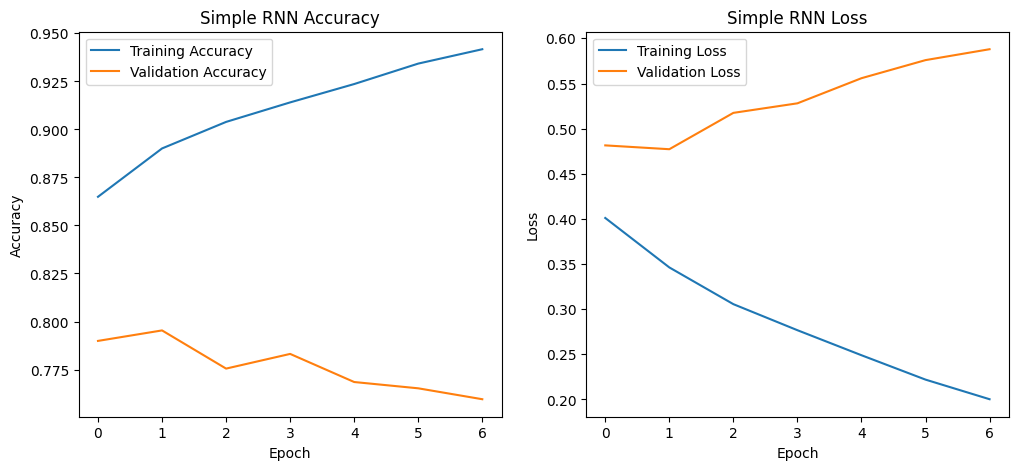

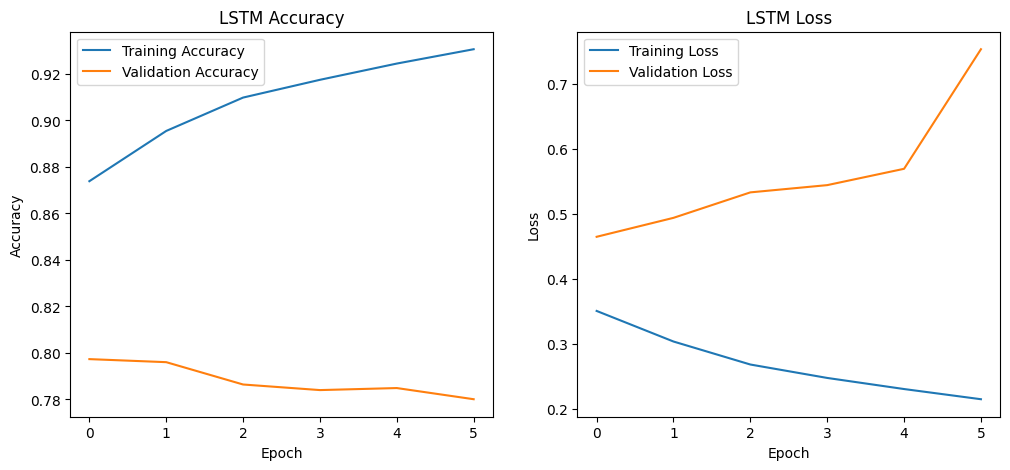

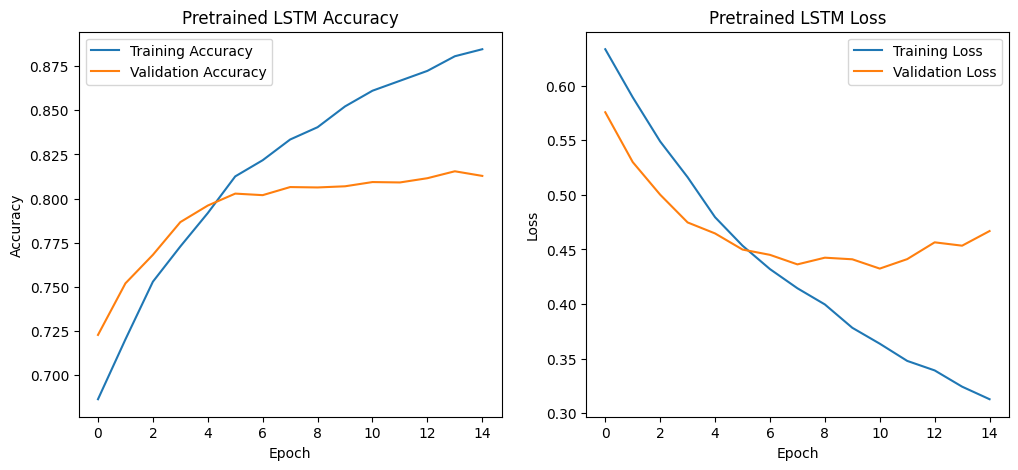

In [ ]:
def plot_history(history, model_name):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()

plot_history(history_rnn, "Simple RNN")
plot_history(history_lstm, "LSTM")
plot_history(history_pretrained, "Pretrained LSTM")


# 15. Evaluation Function


In [ ]:
def get_predictions(model, X_test_pad):
    predictions = model.predict(X_test_pad)

    if num_classes == 2:
        predicted_labels = (predictions > 0.5).astype("int32").flatten()
    else:
        predicted_labels = np.argmax(predictions, axis=1)

    return predicted_labels


def evaluate_model(model, model_name):
    y_pred = get_predictions(model, X_test_pad)

    accuracy = accuracy_score(y_test, y_pred)

    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print("Accuracy:", accuracy)

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_.astype(str)
    ))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    return accuracy


# 16. Evaluate All Models


179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Model 1: Simple RNN
Accuracy: 0.7730607966457023

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.84      0.80      2997
           1       0.80      0.70      0.74      2727

    accuracy                           0.77      5724
   macro avg       0.78      0.77      0.77      5724
weighted avg       0.78      0.77      0.77      5724



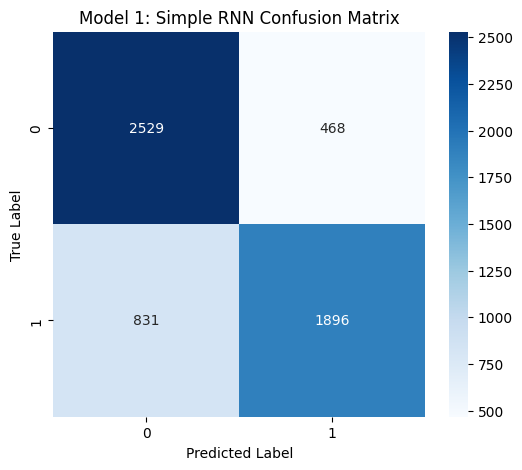

179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
Model 2: LSTM
Accuracy: 0.7791754018169113

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.79      0.79      2997
           1       0.77      0.76      0.77      2727

    accuracy                           0.78      5724
   macro avg       0.78      0.78      0.78      5724
weighted avg       0.78      0.78      0.78      5724



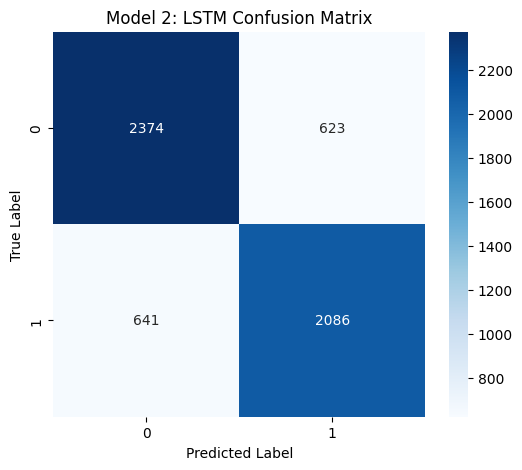

179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Model 3: LSTM with Pretrained Embeddings
Accuracy: 0.8139412997903563

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.84      0.83      2997
           1       0.82      0.79      0.80      2727

    accuracy                           0.81      5724
   macro avg       0.81      0.81      0.81      5724
weighted avg       0.81      0.81      0.81      5724



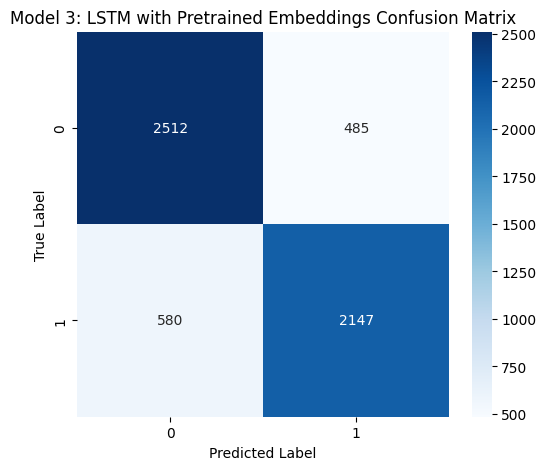

In [ ]:
acc_rnn = evaluate_model(rnn_model, "Model 1: Simple RNN")
acc_lstm = evaluate_model(lstm_model, "Model 2: LSTM")
acc_pretrained = evaluate_model(pretrained_lstm_model, "Model 3: LSTM with Pretrained Embeddings")


# 17. Compare Model Performance


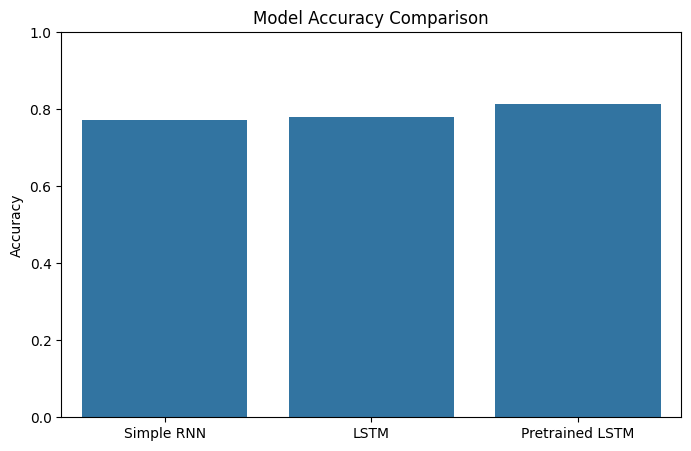

,Model,Accuracy
0,Simple RNN,0.773061
1,LSTM,0.779175
2,Pretrained LSTM,0.813941


In [ ]:
model_names = [
    "Simple RNN",
    "LSTM",
    "Pretrained LSTM"
]

accuracies = [
    acc_rnn,
    acc_lstm,
    acc_pretrained
]

plt.figure(figsize=(8, 5))
sns.barplot(x=model_names, y=accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

comparison_df = pd.DataFrame({
    "Model": model_names,
    "Accuracy": accuracies
})

comparison_df


# 18. Error Analysis


In [ ]:
best_model = pretrained_lstm_model
best_model_name = "Pretrained LSTM"

y_pred_best = get_predictions(best_model, X_test_pad)

error_df = pd.DataFrame({
    "Original Text": X_test.values,
    "True Label": label_encoder.inverse_transform(y_test),
    "Predicted Label": label_encoder.inverse_transform(y_pred_best)
})

misclassified = error_df[error_df["True Label"] != error_df["Predicted Label"]]

print("Total misclassified examples:", len(misclassified))

misclassified.head(3)


179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Total misclassified examples: 1065


,Original Text,True Label,Predicted Label
2,group christie campaign deserter found forest,1,0
4,democratic congressman protest trump environme...,1,0
5,rex tillerson call report ouster laughable,0,1


In [ ]:
for i, row in misclassified.head(3).iterrows():
    print("Tweet:", row["Original Text"])
    print("True Label:", row["True Label"])
    print("Predicted Label:", row["Predicted Label"])
    print("-" * 80)


Tweet: group christie campaign deserter found forest
True Label: 1
Predicted Label: 0
--------------------------------------------------------------------------------
Tweet: democratic congressman protest trump environmental policy bringing endangered red wolf state union guest
True Label: 1
Predicted Label: 0
--------------------------------------------------------------------------------
Tweet: rex tillerson call report ouster laughable
True Label: 0
Predicted Label: 1
--------------------------------------------------------------------------------


# 19. Save Model, Tokenizer, and Label Encoder


In [ ]:
best_model.save("/content/sentiment_lstm_model.h5")

with open("/content/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("/content/label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("Model, tokenizer, and label encoder saved successfully.")


Model, tokenizer, and label encoder saved successfully.


# 20. Real-Time Prediction Function


In [ ]:
def predict_sentiment(text):
    cleaned = clean_text(text)

    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )

    prediction = best_model.predict(padded)

    if num_classes == 2:
        label_index = int(prediction[0][0] > 0.5)
        confidence = prediction[0][0] if label_index == 1 else 1 - prediction[0][0]
    else:
        label_index = np.argmax(prediction, axis=1)[0]
        confidence = np.max(prediction)

    sentiment = label_encoder.inverse_transform([label_index])[0]

    return sentiment, float(confidence)

sample_text = "I love this product, it is amazing!"
predict_sentiment(sample_text)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


(np.int64(0), 0.9568352699279785)

# 21. Gradio GUI for Real-Time Prediction


In [ ]:
!pip install gradio -q


In [ ]:
import gradio as gr

def gradio_predict(tweet):
    sentiment, confidence = predict_sentiment(tweet)

    return {
        "Predicted Sentiment": str(sentiment),
        "Confidence": round(confidence, 4)
    }

interface = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Textbox(
        lines=4,
        placeholder="Enter a tweet here..."
    ),
    outputs="json",
    title="Real-Time Tweet Sentiment Analysis",
    description="Enter a tweet and the trained LSTM model will predict its sentiment."
)

interface.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0bbb102e6395b67eb5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
